
Accuracy Comparison:
Decision Tree Accuracy 0.6
Random Forest Accuracy: 0.6777777777777778

Decision Tree Confusion Matrix: 
 [[29 16]
 [20 25]]

Random Forest Confusion Matrix: 
 [[27 18]
 [11 34]]


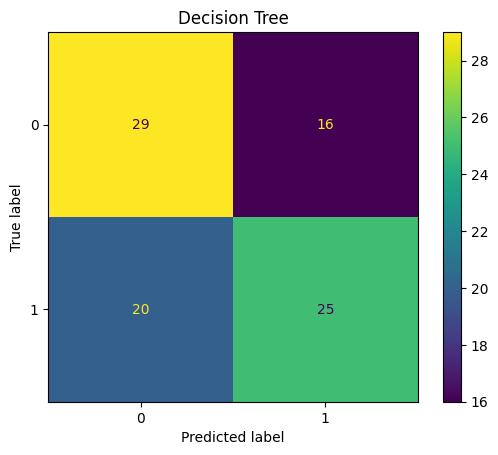

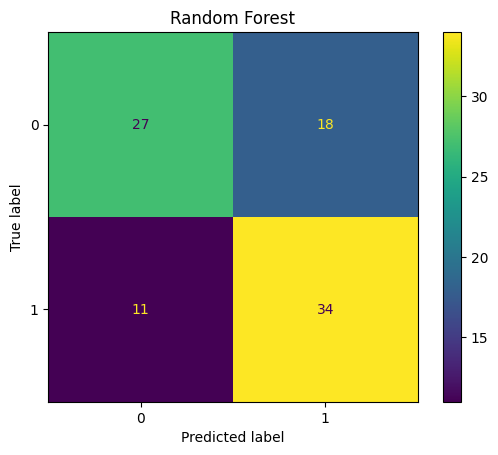

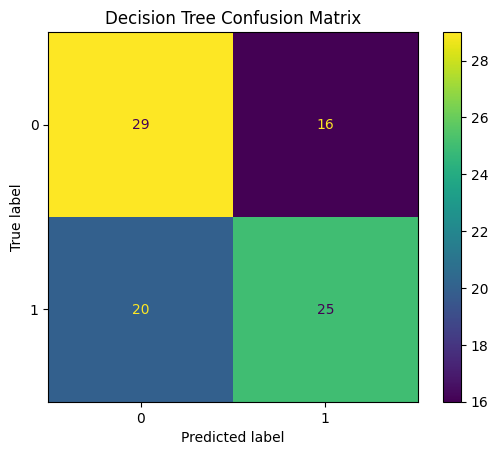

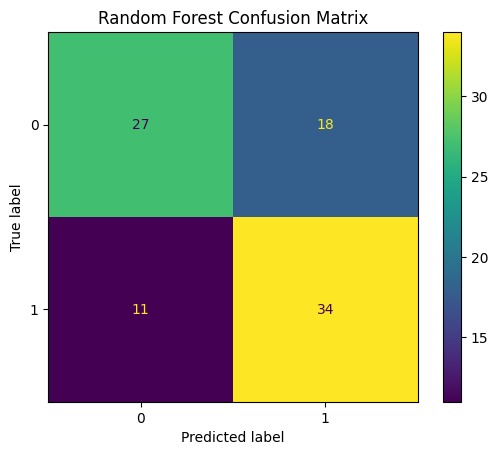


Cross Validation Accuracy:
Decision Tree: 0.5633333333333332
Random Forest: 0.6533333333333333

Feature Importance:
        Feature  Importance
1         Soil    0.229849
7       Season    0.141280
3     Humidity    0.138198
0      Weather    0.133490
6     CropType    0.120395
2  Temperature    0.117968
4         Wind    0.062467
5   Fertilizer    0.056353


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
np.random.seed(42)
random.seed(42)
n_samples = 300
data = {
    'Weather': np.random.choice(['Sunny', 'Cloudy', 'Rainy'], n_samples),
    'Soil': np.random.choice(['Dry', 'Moist', 'Wet'], n_samples),
    'Temperature': np.random.choice(['Hot', 'Mild', 'Cool'], n_samples),
    'Humidity': np.random.choice(['High', 'Medium', 'Low'], n_samples),
    'Wind': np.random.choice(['Strong', 'Weak'], n_samples),
    'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
    'CropType': np.random.choice(['Wheat', 'Rice', 'Corn'], n_samples),
    'Season': np.random.choice(['Kharif', 'Rabi', 'Summer'], n_samples)
}
df = pd.DataFrame(data)
def irrigation_rule(row):
    if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
        base = 'Yes'
    elif row['Soil'] == 'Wet':
        base = 'No'
    else:
        base = random.choice(['Yes', 'No'])
    if random.random() < 0.2:
        return 'No' if base == 'Yes' else 'Yes'
    return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)
#4. Encode Data
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
#5. Split Data
X = df.drop('Irrigate', axis=1)
y = df['Irrigate']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# 6. Decision Tree (High Variance)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
#7. Random Forest (Variance Reduction)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
#8. Accuracy Comparison
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)
print("\nAccuracy Comparison:")
print("Decision Tree Accuracy", dt_acc)
print("Random Forest Accuracy:", rf_acc)
#9. Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0,1])
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0,1])
print("\nDecision Tree Confusion Matrix: \n", cm_dt)
print("\nRandom Forest Confusion Matrix: \n", cm_rf)
#10. Visual Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest")
plt.show()
#11. Confusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()
#12. Cross Validation
dt_cv = cross_val_score(dt_model, X, y, cv=5)
rf_cv = cross_val_score(rf_model, X, y, cv=5)
print("\nCross Validation Accuracy:")
print("Decision Tree:", dt_cv.mean())
print("Random Forest:", rf_cv.mean())
# 13. Feature Importance (Random Forest)
importance = pd.DataFrame({
'Feature': X.columns,
'Importance': rf_model.feature_importances_ }).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:\n", importance)